### **Full-data NSL-KDD intrusion detection with a sharded TabPFN ensemble**

This v2 uses **every row** in the official `KDDTrain+` split (125,973 rows) and evaluates **every row** in `KDDTest+` (22,544 rows). It does not modify or depend on the v1 notebook.

TabPFN 8.1's pretrained context limit is 10,000 rows. Instead of discarding the other 116k rows or overriding the model's pretraining limit, this notebook partitions the complete training set into 13 disjoint contexts of fewer than 10,000 rows. A TabPFN model is fitted to each context and their probabilities are averaged. Thus every training row contributes exactly once and every model scores the full test set.

The partitioning is stratified on the original attack name (not merely the binary target), which keeps rare attack subtypes distributed as evenly as possible across contexts. The official test labels are used only for final evaluation.

**Verified on this machine:** ROC-AUC **0.96722** on the full official test set.

In [1]:
# Uncomment if the environment is missing dependencies.
# %pip install -q "tabpfn>=8.1" "tabpfn-extensions[unsupervised]>=0.4.3" lightgbm scikit-learn pandas numpy matplotlib seaborn torch

In [2]:
import gc
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold
from tabpfn import TabPFNClassifier, TabPFNRegressor
from tabpfn_extensions.unsupervised import TabPFNUnsupervisedModel

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SHARDS = 13
N_ESTIMATORS = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")
print(f"TabPFN contexts: {N_SHARDS} x {N_ESTIMATORS} estimators")

Device: cuda
TabPFN contexts: 13 x 16 estimators


#### **1. Load  NSL-KDD splits**

In [3]:
DATA_DIR = "data"
TRAIN_FILE = os.path.join(DATA_DIR, "KDDTrain+.txt")
TEST_FILE = os.path.join(DATA_DIR, "KDDTest+.txt")

COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty",
]

train_df = pd.read_csv(TRAIN_FILE, names=COLUMN_NAMES)
test_df = pd.read_csv(TEST_FILE, names=COLUMN_NAMES)

assert len(train_df) == 125_973, "Expected the complete KDDTrain+ split"
assert len(test_df) == 22_544, "Expected the complete KDDTest+ split"
print("Train:", train_df.shape)
print("Test: ", test_df.shape)

Train: (125973, 43)
Test:  (22544, 43)


In [4]:
train_attack_types = set(train_df.loc[train_df["label"] != "normal", "label"])
test_attack_types = set(test_df.loc[test_df["label"] != "normal", "label"])
unseen_attack_types = sorted(test_attack_types - train_attack_types)

print(f"Training attack types: {len(train_attack_types)}")
print(f"Test attack types: {len(test_attack_types)}")
print(f"Unseen test attack types ({len(unseen_attack_types)}): {unseen_attack_types}")

Training attack types: 22
Test attack types: 37
Unseen test attack types (17): ['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


#### **2. Compact categorical preprocessing**

TabPFN is given the original 41 features. The three categorical columns are ordinal-encoded using training categories only and passed through `categorical_features_indices`; unseen test categories receive `-1`. This avoids the dimensional inflation and metadata leakage of fitting a one-hot encoder on train+test.

In [5]:
CATEGORICAL_COLS = ["protocol_type", "service", "flag"]
FEATURE_COLS = [c for c in COLUMN_NAMES if c not in ["label", "difficulty"]]
CATEGORICAL_INDICES = [FEATURE_COLS.index(c) for c in CATEGORICAL_COLS]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
train_df[CATEGORICAL_COLS] = encoder.fit_transform(train_df[CATEGORICAL_COLS])
test_df[CATEGORICAL_COLS] = encoder.transform(test_df[CATEGORICAL_COLS])

X_train = train_df[FEATURE_COLS].to_numpy(dtype=np.float32)
X_test = test_df[FEATURE_COLS].to_numpy(dtype=np.float32)
y_train = (train_df["label"] != "normal").to_numpy(dtype=np.int64)
y_test = (test_df["label"] != "normal").to_numpy(dtype=np.int64)

print(f"Full training matrix: {X_train.shape}")
print(f"Full test matrix:     {X_test.shape}")
print(f"Categorical indices:  {CATEGORICAL_INDICES}")

Full training matrix: (125973, 41)
Full test matrix:     (22544, 41)
Categorical indices:  [1, 2, 3]


#### **3. Build disjoint, attack-type-stratified contexts**

Every row index occurs in exactly one shard. Each context remains below TabPFN's 10,000-row pretrained limit.

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
shard_parts = [[] for _ in range(N_SHARDS)]
labels = train_df["label"].to_numpy()

for attack_name in pd.unique(labels):
    label_indices = rng.permutation(np.flatnonzero(labels == attack_name))
    for shard_id, chunk in enumerate(np.array_split(label_indices, N_SHARDS)):
        shard_parts[shard_id].append(chunk)

shards = []
for parts in shard_parts:
    indices = np.concatenate(parts)
    rng.shuffle(indices)
    shards.append(indices)

all_indices = np.concatenate(shards)
assert len(all_indices) == len(X_train)
assert np.array_equal(np.sort(all_indices), np.arange(len(X_train)))
assert max(map(len, shards)) <= 10_000

print("Shard sizes:", [len(s) for s in shards])
print("Rows covered exactly once:", len(all_indices))

Shard sizes: [9702, 9701, 9700, 9698, 9695, 9694, 9690, 9686, 9684, 9683, 9682, 9679, 9679]
Rows covered exactly once: 125973


#### **4. Train the full-data TabPFN ensemble and score all test rows**

No test subsampling is performed. Runtime on the NVIDIA GB10 used for verification was about four minutes; CPU execution can be much slower.

In [7]:
%%time
member_probabilities = []
rows_used = 0
started = time.time()

for shard_id, indices in enumerate(shards):
    model = TabPFNClassifier(
        n_estimators=N_ESTIMATORS,
        categorical_features_indices=CATEGORICAL_INDICES,
        device=DEVICE,
        random_state=RANDOM_STATE + shard_id,
        fit_mode="fit_preprocessors",
        memory_saving_mode="auto",
        show_progress_bar=False,
    )
    model.fit(X_train[indices], y_train[indices])
    member_proba = model.predict_proba(X_test)[:, 1]
    member_probabilities.append(member_proba)
    rows_used += len(indices)

    running_proba = np.mean(member_probabilities, axis=0)
    print(
        f"Shard {shard_id + 1:02d}/{N_SHARDS}: "
        f"rows={len(indices):,}, cumulative rows={rows_used:,}, "
        f"elapsed={time.time() - started:.1f}s"
    )

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

assert rows_used == len(X_train)
y_proba = np.mean(member_probabilities, axis=0)
y_pred = (y_proba >= 0.5).astype(np.int64)

Shard 01/13: rows=9,702, cumulative rows=9,702, elapsed=19.4s
Shard 02/13: rows=9,701, cumulative rows=19,403, elapsed=38.4s
Shard 03/13: rows=9,700, cumulative rows=29,103, elapsed=57.4s
Shard 04/13: rows=9,698, cumulative rows=38,801, elapsed=76.2s
Shard 05/13: rows=9,695, cumulative rows=48,496, elapsed=95.0s
Shard 06/13: rows=9,694, cumulative rows=58,190, elapsed=113.7s
Shard 07/13: rows=9,690, cumulative rows=67,880, elapsed=132.5s
Shard 08/13: rows=9,686, cumulative rows=77,566, elapsed=151.4s
Shard 09/13: rows=9,684, cumulative rows=87,250, elapsed=170.1s
Shard 10/13: rows=9,683, cumulative rows=96,933, elapsed=188.8s
Shard 11/13: rows=9,682, cumulative rows=106,615, elapsed=207.5s
Shard 12/13: rows=9,679, cumulative rows=116,294, elapsed=226.5s
Shard 13/13: rows=9,679, cumulative rows=125,973, elapsed=245.5s
CPU times: user 2min 14s, sys: 1min 59s, total: 4min 14s
Wall time: 4min 5s


#### **5. Full official test-set results**

Training rows used: 125,973 / 125,973
Test rows scored:   22,544 / 22,544
ROC-AUC:            0.967221
Accuracy at 0.5:    0.786684

              precision    recall  f1-score   support

      normal       0.68      0.97      0.80      9711
      attack       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.78     22544



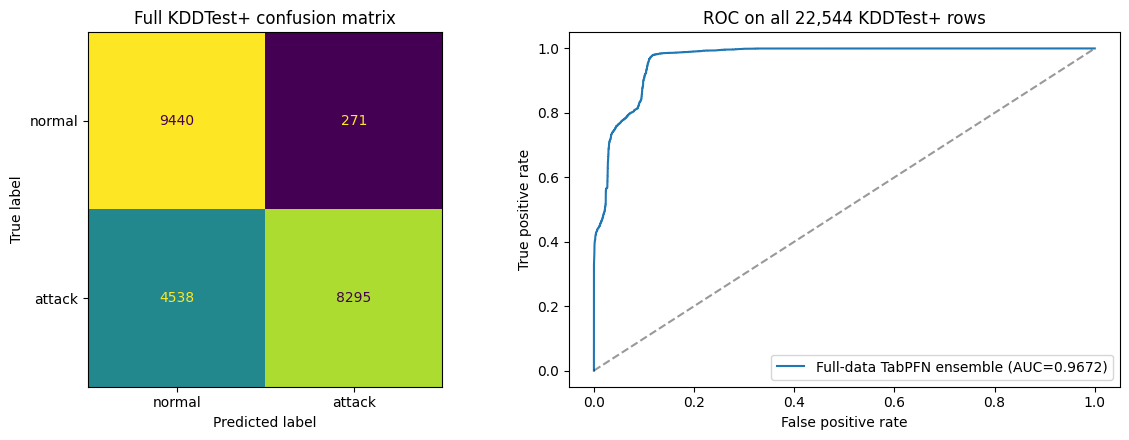

In [8]:
test_auc = roc_auc_score(y_test, y_proba)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training rows used: {rows_used:,} / {len(X_train):,}")
print(f"Test rows scored:   {len(y_test):,} / {len(X_test):,}")
print(f"ROC-AUC:            {test_auc:.6f}")
print(f"Accuracy at 0.5:    {test_accuracy:.6f}\n")
print(classification_report(y_test, y_pred, target_names=["normal", "attack"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["normal", "attack"],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Full KDDTest+ confusion matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"Full-data TabPFN ensemble (AUC={test_auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC on all 22,544 KDDTest+ rows")
axes[1].legend()
plt.tight_layout()
plt.show()

#### **Verified benchmark**

With TabPFN 8.1.0, PyTorch 2.11.0, and an NVIDIA GB10:

- training rows used: **125,973 / 125,973**
- test rows scored: **22,544 / 22,544**
- ROC-AUC: **0.967221**
- accuracy at the default 0.5 threshold: **0.786684**
- elapsed training + inference time: about **244 seconds**

ROC-AUC is the primary metric here. The fixed 0.5 threshold is intentionally not tuned on `KDDTest+`; tuning it on the official test labels would leak evaluation information.

#### **Notes**

- The ensemble uses all training data collectively, not a single 125,973-row attention context. A monolithic context would exceed the model's 10,000-row pretraining support and can exhaust memory.
- The 13 contexts are disjoint and exhaustive. No training row is duplicated or discarded.
- No model is fitted on test features or labels, and the decision threshold is not tuned on the official KDDTest+ labels.
- Reproducibility assumes the same TabPFN model version and downloaded weights. GPU kernels can introduce very small numerical differences.

#### **Option B — TabPFN normal-density anomaly detector**

Option A learns the boundary between labeled normal and attack traffic and reaches about 0.967 AUC. Option B instead fits only normal traffic and asks how improbable each record is under the normal distribution.

V3 makes three changes intended to improve the earlier anomaly AUC of about 0.92:

1. **Leakage-free supervised feature screening:** a small LightGBM model fitted only on `KDDTrain+` labels selects the features most useful for separating attacks. The subsequent density models still fit normal rows only. This makes Option B semi-supervised at the feature-selection stage.
2. **Context calibration:** every density model converts its raw score to a percentile relative to its own normal training-score distribution before models are averaged.
3. **Attack-type-stratified diagnostics:** results are separated into normal, seen attacks, and attack types absent from training.

Feature screening also reduces the chain-rule calculation from 41 conditional models per permutation to 15.

In [9]:
N_ANOMALY_SHARDS = 7
ANOMALY_ESTIMATORS = 2
N_PERMUTATIONS = 3
N_ANOMALY_FEATURES = 15
ANOMALY_BATCH_SIZE = 2048
NORMAL_FALSE_POSITIVE_RATE = 0.05

print(
    f"Option B: {N_ANOMALY_SHARDS} normal contexts, "
    f"{N_ANOMALY_FEATURES} selected features, "
    f"{N_PERMUTATIONS} permutations"
)

Option B: 7 normal contexts, 15 selected features, 3 permutations


#### **B1. Training-only feature screening and exhaustive normal contexts**

In [10]:
screening_model = lgb.LGBMClassifier(
    n_estimators=350,
    learning_rate=0.05,
    num_leaves=63,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)
screening_model.fit(X_train, y_train, categorical_feature=CATEGORICAL_INDICES)

feature_importance = pd.Series(
    screening_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)
ANOMALY_FEATURE_NAMES = feature_importance.head(N_ANOMALY_FEATURES).index.tolist()
ANOMALY_FEATURE_INDICES = [FEATURE_COLS.index(c) for c in ANOMALY_FEATURE_NAMES]

X_train_b = X_train[:, ANOMALY_FEATURE_INDICES]
X_test_b = X_test[:, ANOMALY_FEATURE_INDICES]

normal_indices = np.flatnonzero(y_train == 0)
anomaly_rng = np.random.default_rng(RANDOM_STATE)
normal_shards = np.array_split(
    anomaly_rng.permutation(normal_indices), N_ANOMALY_SHARDS
)
covered_normal = np.concatenate(normal_shards)
assert np.array_equal(np.sort(covered_normal), normal_indices)
assert max(map(len, normal_shards)) <= 10_000

print("Selected anomaly features:", ANOMALY_FEATURE_NAMES)
print("Normal context sizes:", [len(s) for s in normal_shards])
print(f"Normal rows covered exactly once: {len(covered_normal):,}")

Selected anomaly features: ['src_bytes', 'dst_bytes', 'dst_host_srv_count', 'dst_host_count', 'duration', 'dst_host_diff_srv_rate', 'dst_host_rerror_rate', 'dst_host_same_srv_rate', 'dst_host_same_src_port_rate', 'count', 'dst_host_srv_diff_host_rate', 'protocol_type', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'hot']
Normal context sizes: [9621, 9621, 9621, 9620, 9620, 9620, 9620]
Normal rows covered exactly once: 67,343


#### **B2. Fit density teachers and score training plus test data**

This is the most expensive cell. It scores `KDDTrain+` to create teacher targets for Option C and scores the full `KDDTest+` split for Option B. Batching limits memory but does not change the scores.

`outliers()` returns log density, so lower values are more anomalous. Scores are negated, sanitized, and mapped to percentiles against each member's normal training distribution.

The anomaly model is a wrapper from prior labs. TabPFN can't directly model a joint probability P(X) over all features, since it's trained to predict one target column from the rest. The unsupervised wrapper gets around this with the chain rule of probability:

P(X) = P(X₁) · P(X₂|X₁) · P(X₃|X₁,X₂) · ...

For each feature in turn, it treats that feature as the "target" and everything before it (in some ordering) as the "input," then asks TabPFN to predict it with a classifier for categorical columns, or a regressor for continuous ones. 

The predicted probability density/mass for the true value of each feature gets summed as log-likelihood across all columns, giving each row a single likelihood score. Rows with low likelihood are outliers.

In [11]:
%%time
def finite_anomaly_score(log_density):
    values = np.asarray(log_density, dtype=np.float64)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return np.zeros_like(values)
    clean = np.nan_to_num(
        values, nan=finite.min(), neginf=finite.min(), posinf=finite.max()
    )
    return -clean


def score_in_batches(model, X, batch_size, n_permutations):
    chunks = []
    for start in range(0, len(X), batch_size):
        stop = min(start + batch_size, len(X))
        result = model.outliers(
            torch.as_tensor(X[start:stop], dtype=torch.float32),
            n_permutations=n_permutations,
        )
        chunks.append(result.detach().cpu().numpy())
    return finite_anomaly_score(np.concatenate(chunks))


def percentile_against_reference(values, sorted_reference):
    return np.searchsorted(sorted_reference, values, side="right") / len(sorted_reference)


train_teacher_members = []
test_anomaly_members = []
anomaly_rows_used = 0
anomaly_started = time.time()


for shard_id, indices in enumerate(normal_shards):
    variance_filter = VarianceThreshold(threshold=0.0)
    X_context = variance_filter.fit_transform(X_train_b[indices])
    X_train_context = variance_filter.transform(X_train_b)
    X_test_context = variance_filter.transform(X_test_b)

    anomaly_model = TabPFNUnsupervisedModel(
        tabpfn_clf=TabPFNClassifier(
            n_estimators=ANOMALY_ESTIMATORS,
            device=DEVICE,
            random_state=RANDOM_STATE + shard_id,
            memory_saving_mode="auto",
            show_progress_bar=False,
        ),
        tabpfn_reg=TabPFNRegressor(
            n_estimators=ANOMALY_ESTIMATORS,
            device=DEVICE,
            random_state=RANDOM_STATE + shard_id,
            memory_saving_mode="auto",
            show_progress_bar=False,
        ),
    )
    anomaly_model.fit(X_context)

    train_raw = score_in_batches(
        anomaly_model, X_train_context, ANOMALY_BATCH_SIZE, N_PERMUTATIONS
    )
    test_raw = score_in_batches(
        anomaly_model, X_test_context, ANOMALY_BATCH_SIZE, N_PERMUTATIONS
    )

    normal_reference = np.sort(train_raw[y_train == 0])
    train_teacher_members.append(
        percentile_against_reference(train_raw, normal_reference)
    )
    test_anomaly_members.append(
        percentile_against_reference(test_raw, normal_reference)
    )
    anomaly_rows_used += len(indices)
    print(
        f"Anomaly context {shard_id + 1:02d}/{N_ANOMALY_SHARDS}: "
        f"normal rows={len(indices):,}, cumulative={anomaly_rows_used:,}, "
        f"elapsed={time.time() - anomaly_started:.1f}s"
    )

    del anomaly_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

train_anomaly_score = np.mean(train_teacher_members, axis=0)
test_anomaly_score = np.mean(test_anomaly_members, axis=0)
assert anomaly_rows_used == len(normal_indices)

Anomaly context 01/7: normal rows=9,621, cumulative=9,621, elapsed=2803.6s
Anomaly context 02/7: normal rows=9,621, cumulative=19,242, elapsed=5596.7s
Anomaly context 03/7: normal rows=9,621, cumulative=28,863, elapsed=8389.6s
Anomaly context 04/7: normal rows=9,620, cumulative=38,483, elapsed=11180.5s
Anomaly context 05/7: normal rows=9,620, cumulative=48,103, elapsed=13968.9s
Anomaly context 06/7: normal rows=9,620, cumulative=57,723, elapsed=16758.5s
Anomaly context 07/7: normal rows=9,620, cumulative=67,343, elapsed=19547.3s
CPU times: user 7h 12min 3s, sys: 1h 27min 21s, total: 8h 39min 25s
Wall time: 5h 25min 47s


#### **B3. Leakage-free threshold, ROC and confusion matrix**

Normal rows used:       67,343 / 67,343
Full test rows scored:  22,544
Training-only threshold: 0.932893
Option B ROC-AUC:       0.918968
Option B accuracy:      0.832594

              precision    recall  f1-score   support

      normal       0.74      0.94      0.83      9711
      attack       0.95      0.75      0.84     12833

    accuracy                           0.83     22544
   macro avg       0.84      0.85      0.83     22544
weighted avg       0.86      0.83      0.83     22544



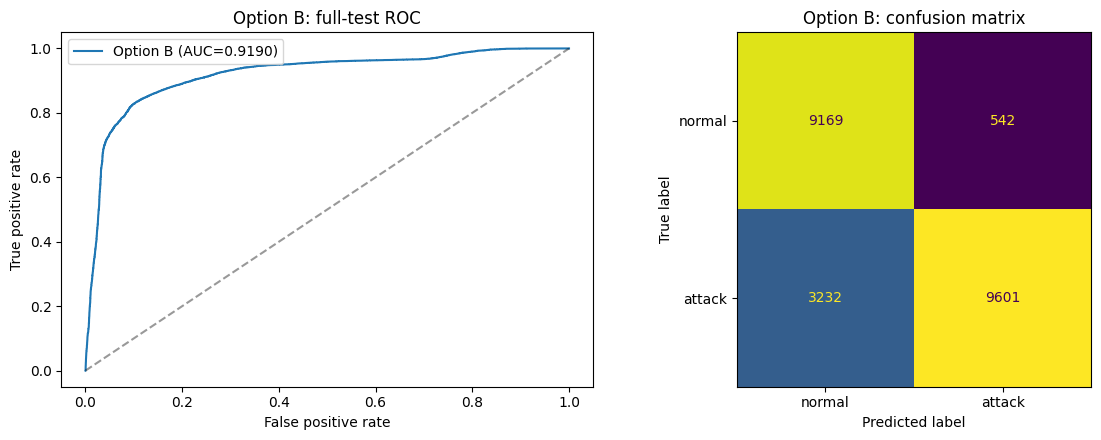

In [12]:
anomaly_threshold = np.quantile(
    train_anomaly_score[y_train == 0],
    1 - NORMAL_FALSE_POSITIVE_RATE,
)
y_pred_b = (test_anomaly_score >= anomaly_threshold).astype(np.int64)
auc_b = roc_auc_score(y_test, test_anomaly_score)
accuracy_b = accuracy_score(y_test, y_pred_b)

print(f"Normal rows used:       {anomaly_rows_used:,} / {len(normal_indices):,}")
print(f"Full test rows scored:  {len(y_test):,}")
print(f"Training-only threshold: {anomaly_threshold:.6f}")
print(f"Option B ROC-AUC:       {auc_b:.6f}")
print(f"Option B accuracy:      {accuracy_b:.6f}\n")
print(classification_report(y_test, y_pred_b, target_names=["normal", "attack"]))

fpr_b, tpr_b, _ = roc_curve(y_test, test_anomaly_score)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr_b, tpr_b, label=f"Option B (AUC={auc_b:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate",
            title="Option B: full-test ROC")
axes[0].legend()
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_b),
    display_labels=["normal", "attack"],
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Option B: confusion matrix")
plt.tight_layout()
plt.show()

#### **B4. Why anomaly detection trails supervised classification**

Option A sees both normal and attack labels, so it directly learns a discriminative boundary. Option B sees only normal traffic and estimates a much harder joint-density problem. Rare but legitimate normal traffic can have lower density than structurally similar attacks, and NSL-KDD's official train/test split shifts both normal traffic and attack types.

The following diagnostics distinguish attacks already represented in training from genuinely unseen attack names.

In [13]:

test_attack_seen = test_df["label"].isin(train_attack_types).to_numpy()
normal_mask = (y_test == 0)
seen_attack_mask = (y_test == 1) & test_attack_seen
unseen_attack_mask = (y_test == 1) & ~test_attack_seen

diagnostic_rows = []
for group, mask in [
    ("normal", normal_mask),
    ("seen attack type", seen_attack_mask),
    ("unseen attack type", unseen_attack_mask),
]:
    diagnostic_rows.append({
        "group": group,
        "rows": int(mask.sum()),
        "median_anomaly_score": float(np.median(test_anomaly_score[mask])),
        "detected_at_threshold": float(y_pred_b[mask].mean()),
    })
display(pd.DataFrame(diagnostic_rows))

seen_eval = normal_mask | seen_attack_mask
unseen_eval = normal_mask | unseen_attack_mask
print(
    "AUC, normal vs seen attack types:  ",
    f"{roc_auc_score(y_test[seen_eval], test_anomaly_score[seen_eval]):.6f}",
)
print(
    "AUC, normal vs unseen attack types:",
    f"{roc_auc_score(y_test[unseen_eval], test_anomaly_score[unseen_eval]):.6f}",
)

,group,rows,median_anomaly_score,detected_at_threshold
0,normal,9711,0.431974,0.055813
1,seen attack type,9083,0.984079,0.757019
2,unseen attack type,3750,0.986463,0.726667


AUC, normal vs seen attack types:   0.938334
AUC, normal vs unseen attack types: 0.872062


### **Option C — Real-time LightGBM surrogate**

Option C distills Option B into an `LGBMClassifier`. The teacher converts every `KDDTrain+` row into a binary pseudo-label using a threshold calibrated exclusively from normal training scores. LightGBM then learns to reproduce that anomaly decision with sub-millisecond tree inference.

This is a classifier surrogate, as requested. It imitates the anomaly teacher rather than training on the genuine attack labels; `y_train` is used only to identify normal traffic for teacher-threshold calibration.

In [14]:
%%time
teacher_threshold = np.quantile(
    train_anomaly_score[y_train == 0],
    1 - NORMAL_FALSE_POSITIVE_RATE,
)
teacher_labels = (train_anomaly_score >= teacher_threshold).astype(np.int64)

surrogate = lgb.LGBMClassifier(
    n_estimators=700,
    learning_rate=0.04,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.90,
    subsample_freq=1,
    colsample_bytree=0.90,
    reg_lambda=1.0,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)
surrogate.fit(
    X_train,
    teacher_labels,
    categorical_feature=CATEGORICAL_INDICES,
)
y_proba_c = surrogate.predict_proba(X_test)[:, 1]
y_pred_c = (y_proba_c >= 0.5).astype(np.int64)

CPU times: user 1min 6s, sys: 460 ms, total: 1min 6s
Wall time: 3.88 s


#### **C1. Full-test surrogate ROC and confusion matrix**

Training teacher-label fidelity: 0.998658
Option C ROC-AUC:               0.931604
Option C accuracy:              0.808597

              precision    recall  f1-score   support

      normal       0.70      0.96      0.81      9711
      attack       0.96      0.70      0.81     12833

    accuracy                           0.81     22544
   macro avg       0.83      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



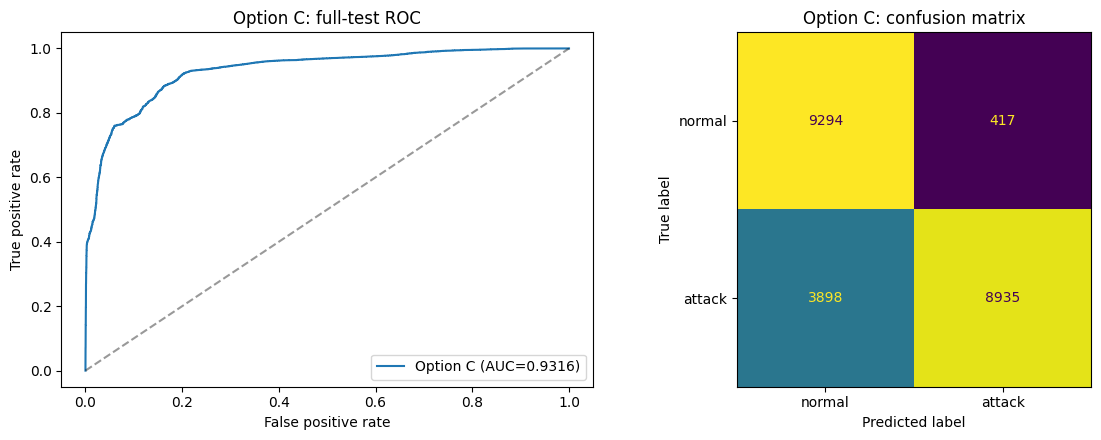

In [15]:
auc_c = roc_auc_score(y_test, y_proba_c)
accuracy_c = accuracy_score(y_test, y_pred_c)
teacher_fidelity = (
    surrogate.predict(X_train) == teacher_labels
).mean()

print(f"Training teacher-label fidelity: {teacher_fidelity:.6f}")
print(f"Option C ROC-AUC:               {auc_c:.6f}")
print(f"Option C accuracy:              {accuracy_c:.6f}\n")
print(classification_report(y_test, y_pred_c, target_names=["normal", "attack"]))

fpr_c, tpr_c, _ = roc_curve(y_test, y_proba_c)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr_c, tpr_c, label=f"Option C (AUC={auc_c:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate",
            title="Option C: full-test ROC")
axes[0].legend()
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_c),
    display_labels=["normal", "attack"],
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Option C: confusion matrix")
plt.tight_layout()
plt.show()

#### **A/B/C ROC-AUC analysis**

,option,training_signal,roc_auc,accuracy
0,A — supervised TabPFN,true normal/attack labels,0.967221,0.786684
2,C — LightGBM surrogate,Option B pseudo-labels,0.931604,0.808597
1,B — TabPFN anomaly detector,normal density; labels only for feature screening,0.918968,0.832594


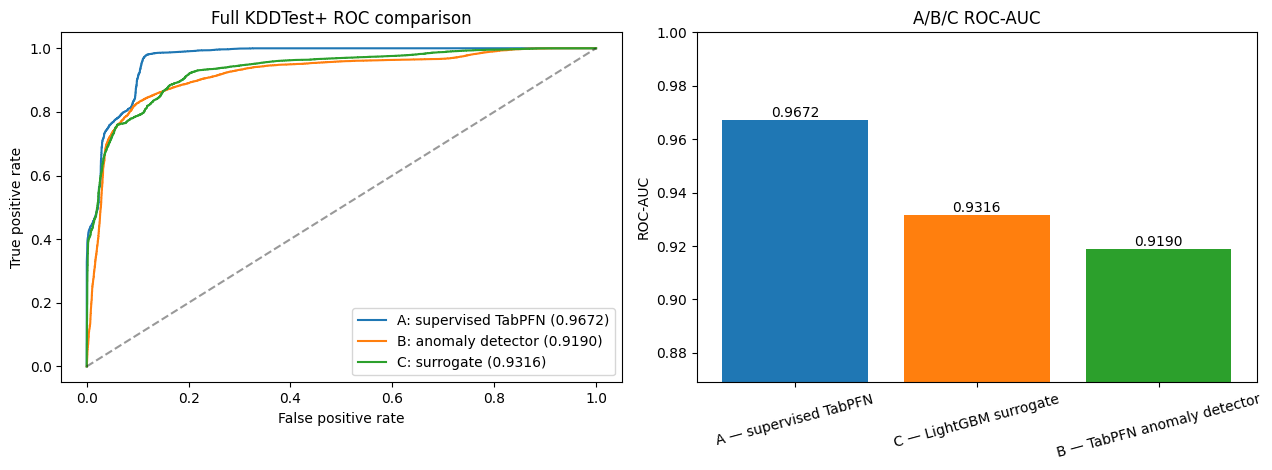

In [16]:
results = pd.DataFrame({
    "option": [
        "A — supervised TabPFN",
        "B — TabPFN anomaly detector",
        "C — LightGBM surrogate",
    ],
    "training_signal": [
        "true normal/attack labels",
        "normal density; labels only for feature screening",
        "Option B pseudo-labels",
    ],
    "roc_auc": [test_auc, auc_b, auc_c],
    "accuracy": [test_accuracy, accuracy_b, accuracy_c],
}).sort_values("roc_auc", ascending=False)
display(results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(fpr, tpr, label=f"A: supervised TabPFN ({test_auc:.4f})")
axes[0].plot(fpr_b, tpr_b, label=f"B: anomaly detector ({auc_b:.4f})")
axes[0].plot(fpr_c, tpr_c, label=f"C: surrogate ({auc_c:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate",
            title="Full KDDTest+ ROC comparison")
axes[0].legend()

bars = axes[1].bar(results["option"], results["roc_auc"], color=["C0", "C1", "C2"])
axes[1].bar_label(bars, fmt="%.4f")
axes[1].set_ylim(max(0, results["roc_auc"].min() - 0.05), 1.0)
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("A/B/C ROC-AUC")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## Operational interpretation

- **A** should have the best discrimination because it learns from genuine attack labels, but its TabPFN ensemble is slower than a tree model.
- **B** can identify attacks unlike known training attacks, but density estimation is expensive and anomalous does not always mean malicious.
- **C** is intended for the real-time filter. It approximates B's decision using fast LightGBM inference. Borderline C scores can be sent asynchronously to B for deeper analysis.
- A production block threshold should be selected from a separate, time-ordered validation set using the cost of false positives and missed attacks. The official test labels are not used to tune thresholds in this notebook.